Extract data for target words: on, off, yes, no and random (uknown) words

In [1]:
import os
import librosa
import numpy as np
import random

DATASET_PATH = "D:/Data Sets/speech_commands_v0.02/" 
TARGET_WORDS = ["on", "off", "yes", "no"] 
NUM_SAMPLES = 3745

X_prod = []
y_prod = []
MAX_PAD_LEN = 32 
SR = 16000 

print("Starting Extraction")

# 1. Extract Target Words 
for label_idx, word in enumerate(TARGET_WORDS):
    word_dir = os.path.join(DATASET_PATH, word)
    files = [f for f in os.listdir(word_dir) if f.endswith('.wav')]
    random.shuffle(files) # Shuffle to prevent alphabetical bias
    
    print(f"Processing '{word}' Data, Transforming into cepstral features")
    added_for_this_word = 0
    
    for file_name in files:
        if added_for_this_word >= NUM_SAMPLES:
            break # Stop exactly when we hit 3745 for set balancing
            
        file_path = os.path.join(word_dir, file_name)
        try:
            audio, _ = librosa.load(file_path, sr=SR)
            mfcc = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=40) # get first 40 cepestral coefficients
            
            if mfcc.shape[1] < MAX_PAD_LEN:
                pad_width = MAX_PAD_LEN - mfcc.shape[1]
                mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant') # pad to get 32 frames
            else:
                mfcc = mfcc[:, :MAX_PAD_LEN] # cut at 32 frames
                
            X_prod.append(mfcc)
            y_prod.append(label_idx) 
            added_for_this_word += 1 
        except Exception:
            pass

# 2. Extract Background Noise (First part of unknown class)
print("Slicing continuous background noise into 1-second chunks")
bg_folder = os.path.join(DATASET_PATH, "_background_noise_")
bg_files = [f for f in os.listdir(bg_folder) if f.endswith('.wav')]

noise_chunks_added = 0
for file_name in bg_files:
    file_path = os.path.join(bg_folder, file_name)
    try:
        audio, _ = librosa.load(file_path, sr=SR)
        for start_idx in range(0, len(audio) - SR, SR): # cut the audio file to chuncks of length of 1 second (16000 samples)
            if noise_chunks_added >= (NUM_SAMPLES // 2): 
                break
                
            chunk = audio[start_idx : start_idx + SR]
            mfcc = librosa.feature.mfcc(y=chunk, sr=SR, n_mfcc=40)
            
            if mfcc.shape[1] < MAX_PAD_LEN:
                pad_width = MAX_PAD_LEN - mfcc.shape[1]
                mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
            else:
                mfcc = mfcc[:, :MAX_PAD_LEN]
                
            X_prod.append(mfcc)
            y_prod.append(4) # Class 4 is our 'unknown'
            noise_chunks_added += 1
    except Exception:
        pass

# 3. Extract Wrong Words (Bulletproofed)
print("Adding random wrong words")
# get folders that are not in target words and not background noise
unknown_folders = [f for f in os.listdir(DATASET_PATH) if f not in TARGET_WORDS and f != "_background_noise_" and os.path.isdir(os.path.join(DATASET_PATH, f))]

# Pool ALL possible wrong files into one massive list first
all_wrong_files = []
for folder in unknown_folders:
    folder_dir = os.path.join(DATASET_PATH, folder)
    files = [os.path.join(folder_dir, f) for f in os.listdir(folder_dir) if f.endswith('.wav')]
    all_wrong_files.extend(files)

random.shuffle(all_wrong_files) # Mix all words

needed_wrong_words = NUM_SAMPLES - noise_chunks_added
words_added = 0

for file_path in all_wrong_files:
    if words_added >= needed_wrong_words:
        break # Stop  when the unknown class hits 3745
        
    try:
        audio, _ = librosa.load(file_path, sr=SR)
        mfcc = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=40)
        
        if mfcc.shape[1] < MAX_PAD_LEN:
            pad_width = MAX_PAD_LEN - mfcc.shape[1]
            mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :MAX_PAD_LEN]
            
        X_prod.append(mfcc)
        y_prod.append(4)
        words_added += 1 
    except Exception:
        pass

# 4. Shuffle the dataset
print("Shuffling final dataset...")
combined = list(zip(X_prod, y_prod))
random.shuffle(combined)
X_prod, y_prod = zip(*combined)

X_prod = np.array(X_prod)[..., np.newaxis]
y_prod = np.array(y_prod)

print("\nEXTRACTION COMPLETE")
print(f"Final Dataset Shape: {X_prod.shape}")

Starting Extraction
Processing 'on' Data, Transforming into cepstral features
Processing 'off' Data, Transforming into cepstral features
Processing 'yes' Data, Transforming into cepstral features
Processing 'no' Data, Transforming into cepstral features
Slicing continuous background noise into 1-second chunks
Adding random wrong words
Shuffling final dataset...

EXTRACTION COMPLETE
Final Dataset Shape: (18725, 40, 32, 1)


train the  CNN with early stop if performance starts going down

In [2]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

X_train, X_test, y_train, y_test = train_test_split(
    X_prod, y_prod, test_size=0.2, random_state=42, stratify=y_prod
)

print(f"Training on {len(X_train)} samples, testing on {len(X_test)} samples")

model_prod = models.Sequential([
    layers.Input(shape=(40, 32, 1)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'), 
    layers.Dropout(0.5),
    
    layers.Dense(5, activation='softmax')
])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True 
)

model_prod.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nStarting Training")
history_prod = model_prod.fit(
    X_train, y_train, 
    epochs=25, 
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

model_prod.save("speech_commands_1.keras")
print("\nModel saved")

Training on 14980 samples, testing on 3745 samples

Starting Training
Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6644 - loss: 0.8830 - val_accuracy: 0.8270 - val_loss: 0.4579
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8307 - loss: 0.4675 - val_accuracy: 0.8382 - val_loss: 0.4324
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8652 - loss: 0.3677 - val_accuracy: 0.8734 - val_loss: 0.3595
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8861 - loss: 0.3163 - val_accuracy: 0.8825 - val_loss: 0.3038
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9000 - loss: 0.2760 - val_accuracy: 0.8849 - val_loss: 0.3208
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9093 - loss: 0.2538 - val_accuracy: 0.9031 - val_loss: 0.2674
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9178 - loss: 0.2277 - val_accuracy: 0.9007 - val_loss: 0.2595
Epoch 8/25
469/469 ━━━━━━━━━━━━━

Plots

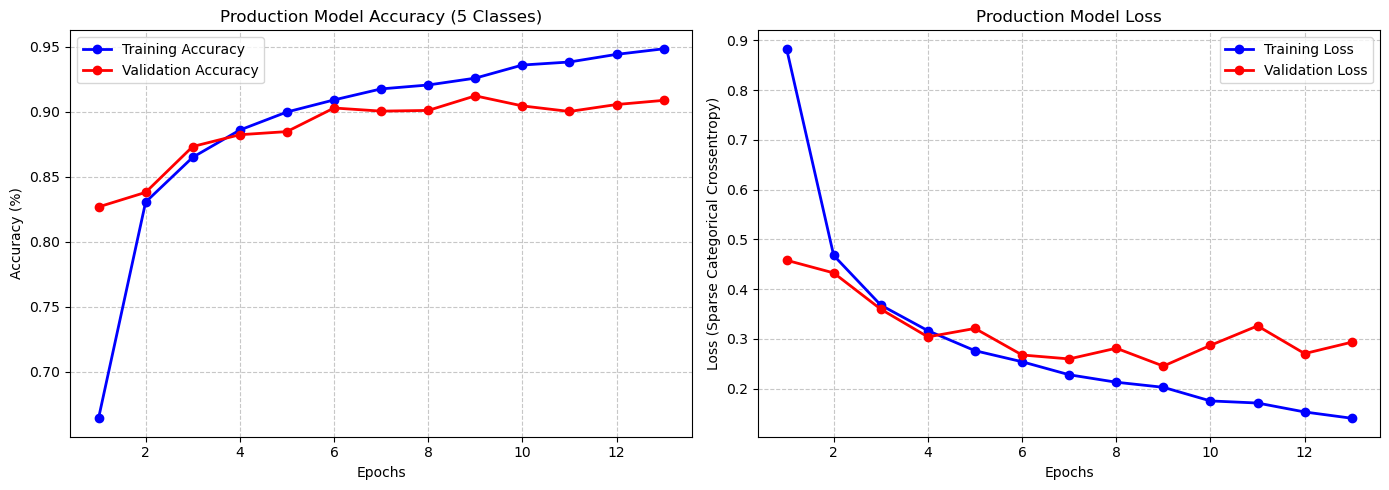

In [3]:
import matplotlib.pyplot as plt

# Extract metrics 
acc = history_prod.history['accuracy']
val_acc = history_prod.history['val_accuracy']
loss = history_prod.history['loss']
val_loss = history_prod.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy 
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy', linewidth=2)
plt.title('Production Model Accuracy (5 Classes)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss', linewidth=2)
plt.title('Production Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (Sparse Categorical Crossentropy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Confusion Matrix

Confusion Matrix on test set
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


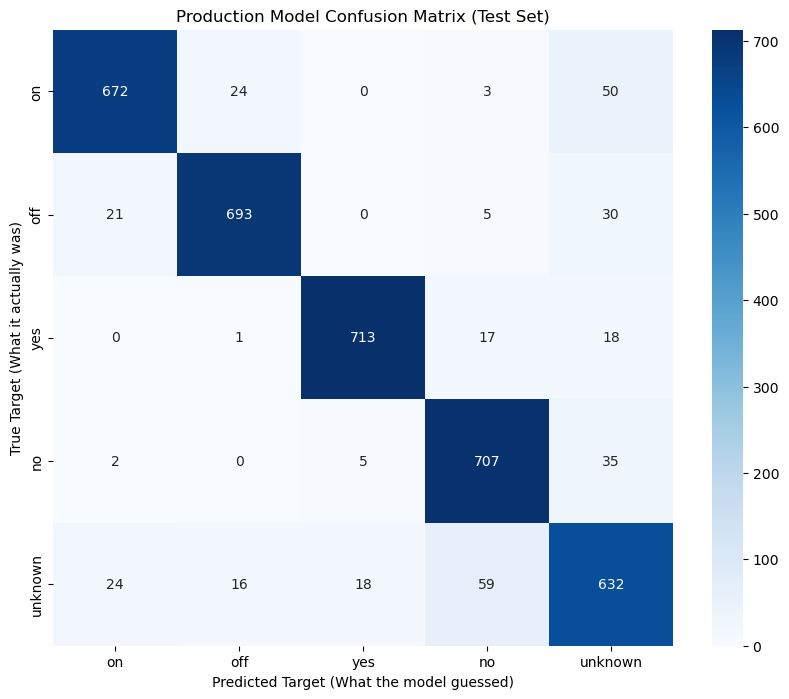

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

CLASSES = ['on', 'off', 'yes', 'no', 'unknown']

print("Confusion Matrix on test set")

# 1. Get the raw probability scores for the entire test set
y_pred_probs = model_prod.predict(X_test)

# 2. Convert probabilities to final class predictions
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Calculate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Plot it using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASSES, 
            yticklabels=CLASSES)
plt.title('Production Model Confusion Matrix (Test Set)')
plt.ylabel('True Target (What it actually was)')
plt.xlabel('Predicted Target (What the model guessed)')
plt.show()

Live Try

In [5]:
import sounddevice as sd
import numpy as np
import librosa
import tensorflow as tf
import time 
import matplotlib.pyplot as plt
import librosa.display
import numpy as np

#1. Load  production model
model = tf.keras.models.load_model('speech_commands_max_capacity.keras')

# Map the output neurons to their actual words
CLASSES = ['on', 'off', 'yes', 'no', 'unknown']

def record_and_predict():
    duration = 1.0  # Exactly 1 second, just like our training data
    sample_rate = 16000 # 16kHz
    
    print("\n Get ready")
    
    for i in range(3, 0, -1):
        print(f"{i}...")
        time.sleep(1) # Pauses the script for exactly 1 second
        
    print("GO! (Recording for 1 second)")
    
    # 2. Record from the live microphone
    audio_data = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1, dtype='float32')
    sd.wait()
    print("Processing...")
    
    # 3. Pre-process the live audio
    audio_data = audio_data.flatten()
    
    # 4. Extract the MFCC Spectrogram
    mfcc = librosa.feature.mfcc(y=audio_data, sr=sample_rate, n_mfcc=40)
    
    # Pad or truncate to match our exact (40, 32) shape
    max_pad_len = 32
    if mfcc.shape[1] < max_pad_len:
        pad_width = max_pad_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_pad_len]
        
    # Add the batch and channel dimensions so the CNN accepts it: (1, 40, 32, 1)
    mfcc_input = mfcc[np.newaxis, ..., np.newaxis]
    
    # 5. Run Inference!
    predictions = model.predict(mfcc_input, verbose=0)
    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index] * 100
    
    # 6. Display the results
    print(f"\n Prediction: {CLASSES[predicted_index].upper()}")
    print(f"Confidence: {confidence:.2f}%")
    
    print("\nProbability Distribution")
    for word, prob in zip(CLASSES, predictions[0]):
        print(f"{word.rjust(7)}: {prob * 100:>5.1f}%")
        
    mfcc_to_plot = np.squeeze(mfcc_input)

    plt.figure(figsize=(8, 4))

    librosa.display.specshow(mfcc_to_plot, sr=16000, x_axis='time', cmap='magma')

    plt.colorbar(format='%+2.0f')
    plt.title('MFCC Input Passed to CNN')
    plt.ylabel('MFCC Coefficients (1 to 40)')
    plt.xlabel('Time (Frames)')
    plt.tight_layout()

    plt.show()


# Run the function
record_and_predict()

ValueError: File not found: filepath=speech_commands_max_capacity.keras. Please ensure the file is an accessible `.keras` zip file.